In [1]:
!pip install xgboost shap joblib scikit-learn

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import joblib
import shap

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)

from xgboost import XGBClassifier

pd.set_option(
    "display.max_columns",
    None
)

In [3]:
from google.colab import files

uploaded = files.upload()

Saving feature_matrix.csv to feature_matrix.csv


In [4]:
filename = list(
    uploaded.keys()
)[0]

df = pd.read_csv(filename)

print(df.shape)

df.head()

(8170, 56)


,id,event_type,latitude,longitude,endlatitude,endlongitude,address,end_address,event_cause,requires_road_closure,start_datetime,end_datetime,status,authenticated,modified_datetime,map_file,direction,description,veh_type,veh_no,corridor,priority,reason_breakdown,created_date,route_path,client_id,created_by_id,last_modified_by_id,assigned_to_police_id,comment,police_station,meta_data,kgid,resolved_at_address,resolved_at_latitude,resolved_at_longitude,closed_by_id,closed_datetime,resolved_by_id,resolved_datetime,gba_identifier,zone,junction,duration_minutes,hour_of_day,day_of_week,month,is_weekend,time_bucket,log_duration,planned_flag,lead_time_hours,event_cause_frequency,corridor_frequency,zone_frequency,is_peak_hour
0,FKID000000,unplanned,13.040004,77.518099,0.000000,0.000000,"Mumbai Bengaluru Highway, Jalahalli Cross Junc...",NaN,vehicle_breakdown,0,2024-03-07 17:01:48.111000+00:00,NaN,closed,yes,2024-03-07 19:35:47.871698+00,NaN,NaN,s m circle in coming man track,lcv,FKN00GL0000,Tumkur Road,High,NaN,2024-03-07 17:03:51.164032+00:00,NaN,1,FKUSR00000,FKUSR00001,NaN,NaN,Peenya,NaN,FKKG000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,West Zone 1,NaN,NaN,17.0,3.0,3.0,0,daytime,NaN,0,0.0,4894,458.0,1196,0
1,FKID000001,unplanned,12.921876,77.645158,0.000000,0.000000,"19th Main Road, Heavie Halcyon, Agara, HSR Lay...",NaN,vehicle_breakdown,0,2024-01-30 04:07:24.173000+00:00,NaN,resolved,yes,2024-01-30 04:17:46.828979+00,NaN,NaN,Starting problem,heavy_vehicle,FKN00GL0001,ORR East 1,High,NaN,2024-01-30 04:08:22.954979+00:00,NaN,1,FKUSR00002,FKUSR00001,NaN,NaN,HSR Layout,NaN,FKKG000001,"19th Main Road, Heavie Halcyon, Agara, HSR Lay...",12.921876,77.645158,NaN,NaN,FKUSR00002,2024-01-30 04:17:46.828355+00:00,NaN,South Zone 2,NaN,NaN,4.0,1.0,1.0,0,early_morning,NaN,0,0.0,4894,244.0,805,1
2,FKID000002,unplanned,12.955622,77.585708,0.000000,0.000000,"Lalbagh Main Road, Dr Sri Shantaveera Swami Ci...",NaN,others,0,2023-11-11 06:18:03.343000+00:00,NaN,closed,yes,2024-01-30 04:56:03.282003+00,NaN,NaN,ಊರ್ವಶಿ ಜಂಕ್ಷನ್ ನಲ್ಲಿ ಒಳಚರಂಡಿ ಚೇಂಬರ್ ಗೆ ಹೊಸದಾಗಿ...,NaN,NaN,Non-corridor,Low,NaN,2023-11-11 06:20:00.989398+00:00,NaN,1,FKUSR00003,FKUSR00001,NaN,NaN,Wilson Garden,NaN,FKKG000002,NaN,NaN,NaN,FKUSR00003,2024-01-30 04:56:03.281509+00:00,NaN,NaN,Bengaluru Central Corporation,Central Zone 2,UrvashiJunction,115117.998975,6.0,5.0,11.0,1,early_morning,11.653722,0,0.0,637,3122.0,1492,1
3,FKID000003,unplanned,13.006147,77.579435,13.006239,77.579516,"Sankey Road, Bashyam Circle, Sadashiva Nagar, ...","Sankey Road, Palace Orchard Upper, Sadashiva N...",tree_fall,1,2024-03-07 17:56:55.061000+00:00,NaN,closed,yes,2024-03-14 07:42:05.55005+00,NaN,NaN,tree fall,NaN,NaN,Non-corridor,Low,NaN,2024-03-07 17:58:56.696892+00:00,NaN,1,FKUSR00004,FKUSR00001,NaN,NaN,Sadashivanagar,NaN,FKKG000003,NaN,NaN,NaN,FKUSR00004,2024-03-14 07:42:05.549440+00:00,NaN,NaN,NaN,West Zone 2,NaN,9465.174807,17.0,3.0,3.0,0,daytime,9.155480,0,0.0,284,3122.0,826,0
4,FKID000004,unplanned,12.953980,77.585233,0.000000,0.000000,"Lalbagh Fort Road, Lalbagh Main Gate Junction,...",NaN,vehicle_breakdown,0,2024-01-30 04:56:32.348000+00:00,NaN,closed,yes,2024-01-30 05:35:17.33908+00,NaN,NaN,[LOCATION] ಪೈಪ್ [PERSON] ವಾಹನ ಆಫ್ ಆಗಿರುತ್ತದೆ ಸರ್,private_bus,FKN00GL0002,Non-corridor,Low,NaN,2024-01-30 04:58:55.937662+00:00,NaN,1,FKUSR00003,FKUSR00001,NaN,NaN,Wilson Garden,NaN,FKKG000002,NaN,NaN,NaN,FKUSR00003,2024-01-30 05:35:17.338283+00:00,NaN,NaN,NaN,Central Zone 2,LalbaghMainGateJunc,38.749838,4.0,1.0,1.0,0,early_morning,3.682606,0,0.0,4894,3122.0,1492,1


In [5]:
df["start_datetime"] = pd.to_datetime(
    df["start_datetime"],
    errors="coerce",
    utc=True
)

In [6]:
df["priority"] = (
    df["priority"]
    .astype(str)
    .str.lower()
)

In [7]:
df["target"] = (
    df["priority"]
    .map({
        "high":1,
        "low":0
    })
)

In [8]:
df = df[
    df["target"]
    .notnull()
]

print(df.shape)

(8170, 57)


In [9]:
FEATURES = [

    "event_cause",

    "event_type",

    "corridor",

    "zone",

    "hour_of_day",

    "day_of_week",

    "requires_road_closure",

    "is_peak_hour",

    "planned_flag"

]

In [10]:
TARGET = "target"

In [11]:
df = df.sort_values(
    "start_datetime"
)

In [12]:
split_index = int(
    len(df) * 0.8
)

In [13]:
train_df = df.iloc[:split_index]

test_df = df.iloc[split_index:]

In [14]:
print(train_df.shape)
print(test_df.shape)

(6536, 57)
(1634, 57)


In [15]:
X_train = train_df[FEATURES]

y_train = train_df[TARGET]

In [16]:
X_test = test_df[FEATURES]

y_test = test_df[TARGET]

In [17]:
categorical_cols = [

    "event_cause",

    "event_type",

    "corridor",

    "zone"

]

In [18]:
numerical_cols = [

    "hour_of_day",

    "day_of_week",

    "requires_road_closure",

    "is_peak_hour",

    "planned_flag"

]

In [19]:
preprocessor = ColumnTransformer(

    transformers=[

        (

            "cat",

            OneHotEncoder(
                handle_unknown="ignore"
            ),

            categorical_cols

        ),

        (

            "num",

            "passthrough",

            numerical_cols

        )

    ]

)

In [20]:
model = XGBClassifier(

    n_estimators=300,

    max_depth=6,

    learning_rate=0.05,

    subsample=0.8,

    colsample_bytree=0.8,

    random_state=42,

    eval_metric="logloss"
)

In [21]:
pipeline = Pipeline(

    [

        ("preprocessor",
         preprocessor),

        ("model",
         model)

    ]

)

In [22]:
pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['event_cause', 'event_type',
                                                   'corridor', 'zone']),
                                                 ('num', 'passthrough',
                                                  ['hour_of_day', 'day_of_week',
                                                   'requires_road_closure',
                                                   'is_peak_hour',
                                                   'planned_flag'])])),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_byleve...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [23]:
predictions = pipeline.predict(
    X_test
)

In [24]:
probabilities = pipeline.predict_proba(
    X_test
)

In [25]:
print(
    classification_report(
        y_test,
        predictions
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       638
           1       1.00      1.00      1.00       996

    accuracy                           1.00      1634
   macro avg       1.00      1.00      1.00      1634
weighted avg       1.00      1.00      1.00      1634



In [26]:
acc = accuracy_score(
    y_test,
    predictions
)

print(
    "Accuracy:",
    round(acc,4)
)

Accuracy: 0.9976


In [27]:
f1 = f1_score(
    y_test,
    predictions
)

print(
    "F1:",
    round(f1,4)
)

F1: 0.998


In [28]:
cm = confusion_matrix(
    y_test,
    predictions
)

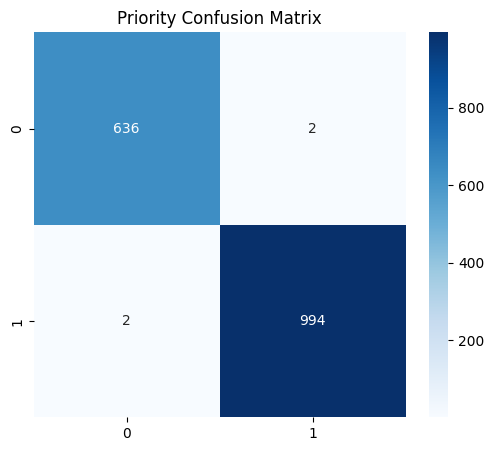

In [29]:
plt.figure(
    figsize=(6,5)
)

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues"

)

plt.title(
    "Priority Confusion Matrix"
)

plt.savefig(
    "confusion_matrix.png"
)

plt.show()

In [30]:
report = classification_report(
    y_test,
    predictions
)

In [31]:
with open(
    "classification_report.txt",
    "w"
) as f:

    f.write(report)

In [32]:
xgb_model = (
    pipeline.named_steps[
        "model"
    ]
)

In [33]:
encoder = (
pipeline.named_steps[
"preprocessor"
]
)

In [34]:
feature_names = (

encoder

.get_feature_names_out()

)

In [35]:
importance = pd.DataFrame({

    "feature":
    feature_names,

    "importance":
    xgb_model.feature_importances_

})

In [36]:
importance = importance.sort_values(

    "importance",

    ascending=False

)

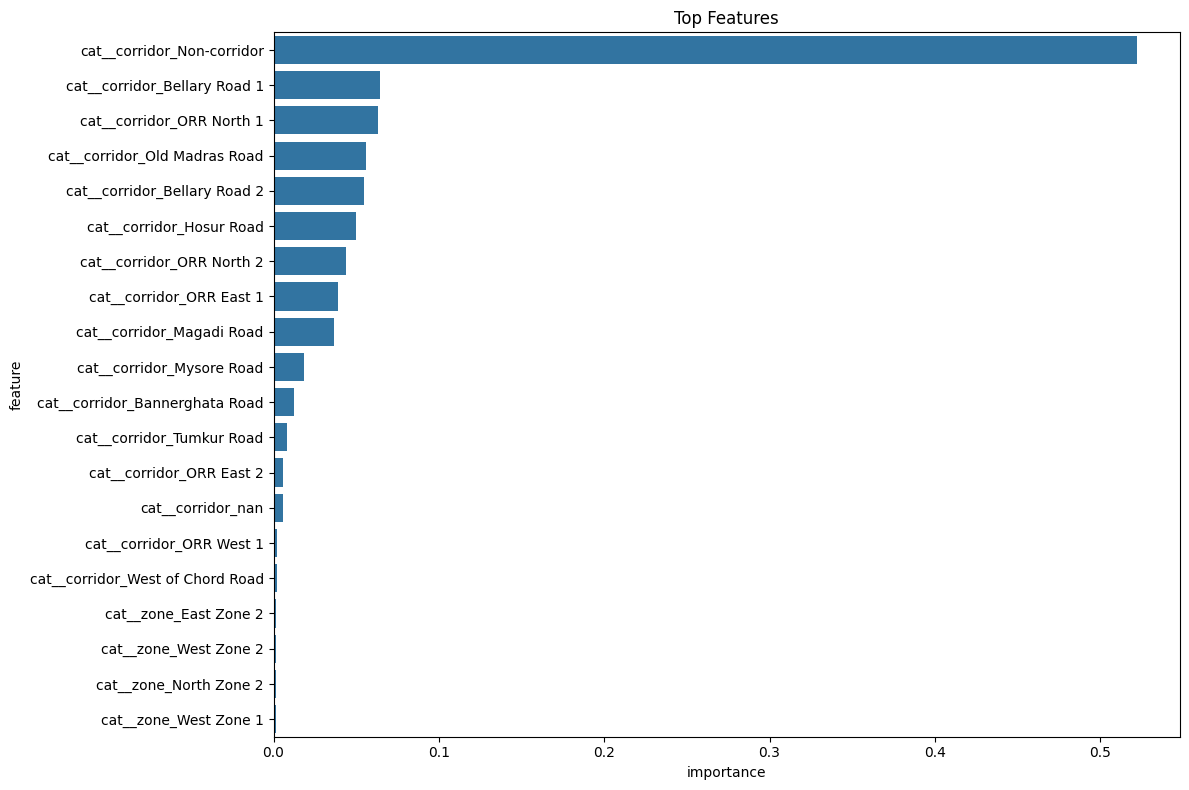

In [37]:
plt.figure(
    figsize=(12,8)
)

sns.barplot(

    data=importance.head(20),

    x="importance",

    y="feature"

)

plt.title(
    "Top Features"
)

plt.tight_layout()

plt.savefig(
    "feature_importance.png"
)

plt.show()

SHAP Setup

In [38]:
X_train_encoded = (

encoder

.transform(X_train)

)

In [39]:
explainer = shap.TreeExplainer(
    xgb_model
)

In [40]:
shap_values = explainer.shap_values(
    X_train_encoded[:500]
)

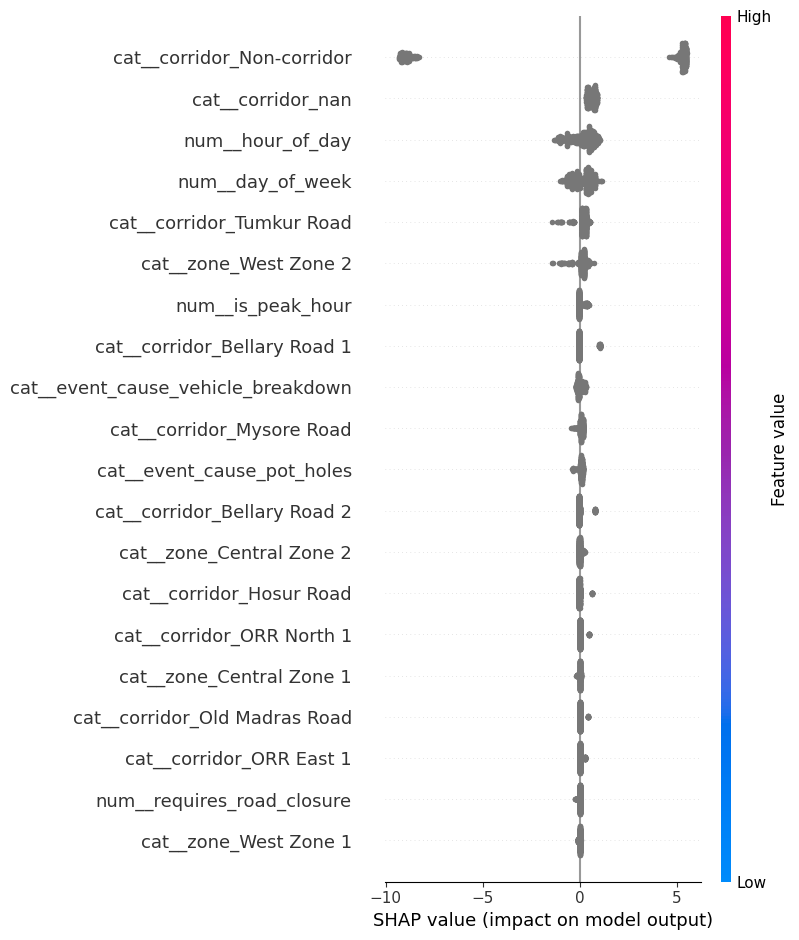

In [41]:
shap.summary_plot(

    shap_values,

    X_train_encoded[:500],

    feature_names=feature_names,

    show=False

)

In [42]:
plt.savefig(
    "shap_summary.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [43]:
joblib.dump(

    pipeline,

    "priority_classifier.pkl"

)

['priority_classifier.pkl']

In [44]:
joblib.dump(

    encoder,

    "feature_encoder.pkl"

)

['feature_encoder.pkl']

In [45]:
joblib.dump(

    FEATURES,

    "feature_columns.pkl"

)

['feature_columns.pkl']

In [46]:
sample = X_test.iloc[[0]]

sample

,event_cause,event_type,corridor,zone,hour_of_day,day_of_week,requires_road_closure,is_peak_hour,planned_flag
1704,vehicle_breakdown,unplanned,Tumkur Road,West Zone 1,18.0,5.0,0,0,0


In [47]:
pipeline.predict(
    sample
)

array([1])